# Phase 1 — Embedding Extraction with BiomedCLIP

This notebook runs **phase 1** of the SAE pipeline:
it extracts visual and text embeddings from the IU X-Ray dataset
using the `chuhac/BiomedCLIP-vit-bert-hf` model.

**Input:**
- `data/iu_xray/images/images_normalized/` — 7 470 PNG chest X-rays
- `data/iu_xray/reports/indiana_reports.csv` — clinical reports

**Output:**
- `embeddings/visual_embeddings.pt` — tensor `(N_img, 512)`
- `embeddings/text_embeddings.pt`  — tensor `(N_rep, 512)`

**Device:** MPS (Apple Silicon) → CUDA → CPU fallback

## 0. Setup & Configuration

In [1]:
import sys
from pathlib import Path

import torch

# Traverse up to the project root
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'src').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / 'src'))
sys.path.insert(0, str(PROJECT_ROOT / 'datasets'))

# Select compute device (MPS > CUDA > CPU)
if torch.backends.mps.is_available():
    DEVICE = 'mps'
elif torch.cuda.is_available():
    DEVICE = 'cuda'
else:
    DEVICE = 'cpu'

print(f'Project root : {PROJECT_ROOT}')
print(f'PyTorch      : {torch.__version__}')
print(f'Device       : {DEVICE}')

Project root : /Users/marcantoniolopez/Documents/github/xai-project-5
PyTorch      : 2.12.0
Device       : mps


In [2]:
import config
from dataclasses import replace

# Build VLMConfig with MPS and absolute paths
vlm_cfg = config.VLMConfig(
    device=DEVICE,
    image_dir=str(PROJECT_ROOT / 'data' / 'iu_xray' / 'images' / 'images_normalized'),
    reports_dir=str(PROJECT_ROOT / 'data' / 'iu_xray' / 'reports'),
    output_dir=str(PROJECT_ROOT / 'embeddings'),
    batch_size=32,   # keep <64 for MPS stability
    num_workers=0,   # 0 = main process (required on macOS)
)

print('=== VLMConfig ===')
print(f'  model       : {vlm_cfg.model_name}')
print(f'  device      : {vlm_cfg.device}')
print(f'  batch_size  : {vlm_cfg.batch_size}')
print(f'  image_dir   : {vlm_cfg.image_dir}')
print(f'  reports_dir : {vlm_cfg.reports_dir}')
print(f'  visual_out  : {vlm_cfg.visual_output_path}')
print(f'  text_out    : {vlm_cfg.text_output_path}')

=== VLMConfig ===
  model       : chuhac/BiomedCLIP-vit-bert-hf
  device      : mps
  batch_size  : 32
  image_dir   : /Users/marcantoniolopez/Documents/github/xai-project-5/data/iu_xray/images/images_normalized
  reports_dir : /Users/marcantoniolopez/Documents/github/xai-project-5/data/iu_xray/reports
  visual_out  : /Users/marcantoniolopez/Documents/github/xai-project-5/embeddings/visual_embeddings.pt
  text_out    : /Users/marcantoniolopez/Documents/github/xai-project-5/embeddings/text_embeddings.pt


## 1. Data Verification

In [3]:
from iu_xray import IUXrayImageDataset, IUXrayTextDataset

image_dataset = IUXrayImageDataset(Path(vlm_cfg.image_dir))
text_dataset  = IUXrayTextDataset(Path(vlm_cfg.reports_dir))

print(f'Images found  : {len(image_dataset)}')
print(f'Reports found : {len(text_dataset)}')

# Visual sample
img, path = image_dataset[0]
print(f'\nSample image: {Path(path).name} — mode={img.mode}, size={img.size}')

# Text sample
text, uid = text_dataset[0]
print(f'Sample text : uid={uid}')
print(f'  → {text[:120]}...')

Immagini trovate : 7470
Report trovati   : 3851

Campione immagine: 1000_IM-0003-1001.dcm.png — mode=RGB, size=(2048, 2496)
Campione testo  : uid=1
  → Findings: The cardiac silhouette and mediastinum size are within normal limits. There is no pulmonary edema. There is no...


## 2. Load BiomedCLIP

In [4]:
from transformers import AutoModel, AutoProcessor

print(f'Loading model: {vlm_cfg.model_name} ...')
processor = AutoProcessor.from_pretrained(vlm_cfg.processor_name, trust_remote_code=True)
model     = AutoModel.from_pretrained(vlm_cfg.model_name, trust_remote_code=True)
model     = model.to(DEVICE)
model.eval()

print(f'Model on {DEVICE} — total parameters: {sum(p.numel() for p in model.parameters()):,}')

/Users/marcantoniolopez/Documents/github/xai-project-5/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Caricamento modello: chuhac/BiomedCLIP-vit-bert-hf ...
Modello su mps — parametri totali: 195,902,721


## 3. Visual Embedding Extraction

In [5]:
from extract_embeddings import extract_visual_embeddings

extract_visual_embeddings(model, processor, image_dataset, vlm_cfg)

# Verify output
visual_emb = torch.load(vlm_cfg.visual_output_path, map_location='cpu', weights_only=True)
print(f'\nvisual_embeddings.pt : {visual_emb.shape}  dtype={visual_emb.dtype}')
print(f'  mean norm          : {visual_emb.norm(dim=-1).mean():.4f}  (expected ~1.0)')


Found 7470 images. Starting extraction...


Images Processing: 100%|██████████| 234/234 [13:07<00:00,  3.36s/it]


Images Embedding Extraction completed. Saving on /Users/marcantoniolopez/Documents/github/xai-project-5/embeddings/visual_embeddings.pt.

visual_embeddings.pt : torch.Size([7470, 512])  dtype=torch.float32
  norma media        : 1.0000  (attesa ~1.0)


## 4. Text Embedding Extraction

In [6]:
from extract_embeddings import extract_text_embeddings

extract_text_embeddings(model, processor, text_dataset, vlm_cfg)

# Verify output
text_emb = torch.load(vlm_cfg.text_output_path, map_location='cpu', weights_only=True)
print(f'\ntext_embeddings.pt : {text_emb.shape}  dtype={text_emb.dtype}')
print(f'  mean norm        : {text_emb.norm(dim=-1).mean():.4f}  (expected ~1.0)')


Found 3851 reports. Starting extraction...


Reports Processing: 100%|██████████| 121/121 [00:58<00:00,  2.07it/s]

Reports Embedding Extraction completed. Saving on /Users/marcantoniolopez/Documents/github/xai-project-5/embeddings/text_embeddings.pt.

text_embeddings.pt : torch.Size([3851, 512])  dtype=torch.float32
  norma media      : 1.0000  (attesa ~1.0)


## 5. Final Sanity Check

ValueError: Too many bins for data range. Cannot create 40 finite-sized bins.

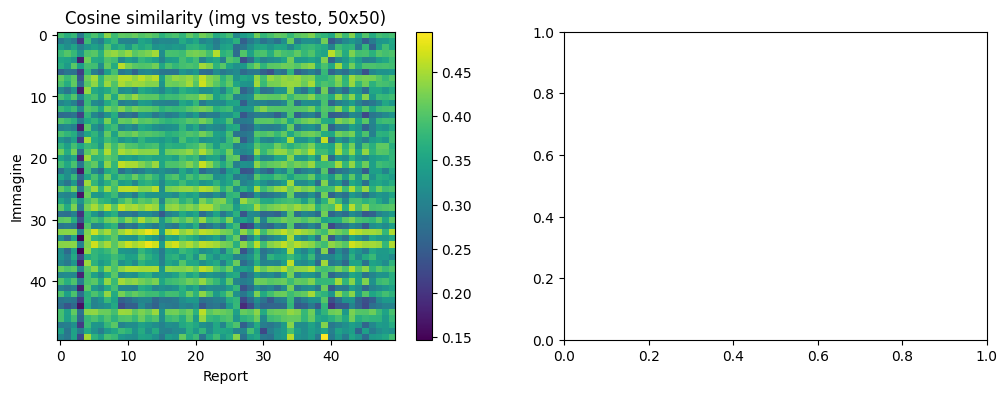

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Load saved embeddings from disk (avoids re-running extraction after kernel restart)
visual_emb = torch.load(
    PROJECT_ROOT / 'embeddings' / 'visual_embeddings.pt',
    map_location='cpu',
    weights_only=True,
)
text_emb = torch.load(
    PROJECT_ROOT / 'embeddings' / 'text_embeddings.pt',
    map_location='cpu',
    weights_only=True,
)

# Cross-modal cosine similarity on a 200-image × 200-report sample
# NOTE: images and reports are NOT aligned by index (different counts),
#       so this shows the distribution of cross-modal similarities, not matched-pair alignment.
vis = visual_emb[:200].float()
txt = text_emb[:200].float()
sim = (vis @ txt.T).numpy()  # (200, 200)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Heatmap
im = axes[0].imshow(sim[:50, :50], cmap='viridis', aspect='auto')
axes[0].set_title('Cross-modal cosine similarity (50 images × 50 reports)')
axes[0].set_xlabel('Report index')
axes[0].set_ylabel('Image index')
plt.colorbar(im, ax=axes[0])

# Norm distribution (embeddings are L2-normalised by BiomedCLIP)
vis_norms = visual_emb.norm(dim=-1).cpu().numpy()
txt_norms = text_emb.norm(dim=-1).cpu().numpy()
all_norms = np.concatenate([vis_norms, txt_norms])
_range    = float(all_norms.max() - all_norms.min())
_bins     = 40 if _range > 1e-6 else 1
axes[1].hist(vis_norms, bins=_bins, alpha=0.7, label='visual')
axes[1].hist(txt_norms, bins=_bins, alpha=0.7, label='text')
axes[1].set_title('Embedding norm distribution')
axes[1].set_xlabel('L2 norm')
axes[1].legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results' / 'figures' / 'embedding_sanity_check.png', dpi=150)
plt.show()

print('\n=== Phase 1 Summary ===')
print(f'  visual_embeddings : {visual_emb.shape}')
print(f'  text_embeddings   : {text_emb.shape}')
print(f'  cross-modal sim   : mean={sim.mean():.4f}  min={sim.min():.4f}  max={sim.max():.4f}')
print('Phase 1 complete.')
